
Our dataset consists of clinical data from patients who entered the hospital complaining of chest pain ("angina") during exercise.  The information collected includes:

* `age` : Age of the patient

* `sex` : Sex of the patient

* `cp` : Chest Pain type

    + Value 0: asymptomatic
    + Value 1: typical angina
    + Value 2: atypical angina
    + Value 3: non-anginal pain
   
    
* `trtbps` : resting blood pressure (in mm Hg)

* `chol` : cholesterol in mg/dl fetched via BMI sensor

* `restecg` : resting electrocardiographic results

    + Value 0: normal
    + Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    + Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

* `thalach` : maximum heart rate achieved during exercise

* `output` : the doctor's diagnosis of whether the patient is at risk for a heart attack
    + 0 = not at risk of heart attack
    + 1 = at risk of heart attack

In [2]:
## library imports here
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, precision_recall_curve
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier


In [3]:
ha = pd.read_csv("https://www.dropbox.com/s/aohbr6yb9ifmc8w/heart_attack.csv?dl=1")
ha.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      273 non-null    int64
 1   sex      273 non-null    int64
 2   cp       273 non-null    int64
 3   trtbps   273 non-null    int64
 4   chol     273 non-null    int64
 5   restecg  273 non-null    int64
 6   thalach  273 non-null    int64
 7   output   273 non-null    int64
dtypes: int64(8)
memory usage: 17.2 KB


In [4]:
ct = ColumnTransformer(
  [
    ("dummify",
    OneHotEncoder(sparse_output = False, handle_unknown='ignore', drop="first"),
    make_column_selector(dtype_include=object)),
    ("standardize",
    StandardScaler(),
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

## Q1: Natural Multiclass Models

Fit a multiclass KNN, Decision Tree, and LDA for the heart disease data; this time predicting the type of chest pain (categories 0 - 3) that a patient experiences.  For the decision tree, plot the fitted tree, and interpret the first couple splits.


In [5]:
# KNN
X = ha[["trtbps","age","chol"]]
y = ha["cp"]

knn_pipeline = Pipeline(
  [("preprocessing", ct),
  ("knn_regressor", KNeighborsClassifier())
  ]
)
param_grid = {
  "knn_regressor__n_neighbors": [1,2,3,4,5,6,7,8,9,10]
}
gscv1 = GridSearchCV(knn_pipeline, param_grid=param_grid, cv = 5, scoring='accuracy')

In [6]:
gscv1_fit = gscv1.fit(X, y)
gscv1_fit

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('dummify',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7ce63f7ff6b0>),
                                                                        ('standardize',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7ce63f05f830>)])),
                                       ('knn_regressor',
                                        KNeighborsClassifier())]),
             param_grid={'knn_regressor__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8,
                                                        9, 10]},
             scoring='accuracy')

In [7]:
print("KNN best params:", gscv1_fit.best_params_)
print("KNN best CV accuracy:", gscv1_fit.best_score_)

KNN best params: {'knn_regressor__n_neighbors': 8}
KNN best CV accuracy: 0.4285521885521885


In [8]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessing", ct),
    ("tree", DecisionTreeClassifier())
])

dt_param_grid = {
    "tree__max_depth": [2,3,4,5,6,8,10, None],
    "tree__min_samples_leaf": [1,2,5,10]
}
dt_grid = GridSearchCV(dt_pipeline,dt_param_grid,cv=5,scoring="accuracy")

In [9]:
dt_grid.fit(X, y)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('dummify',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7ce63f7ff6b0>),
                                                                        ('standardize',
                                                                         StandardScaler(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7ce63f05f830>)])),
                                       ('tree', DecisionTreeClassifier())]),
             param_grid={'tree__max_depth': [2, 3, 4, 5, 6, 8, 10, None],
                         'tree__min_samples_leaf': [1, 2, 5, 10]},
             scoring='accuracy')

In [10]:
print("Decision Tree best params:", dt_grid.best_params_)
print("Decision Tree best CV accuracy:", dt_grid.best_score_)

Decision Tree best params: {'tree__max_depth': 2, 'tree__min_samples_leaf': 1}
Decision Tree best CV accuracy: 0.4432996632996633


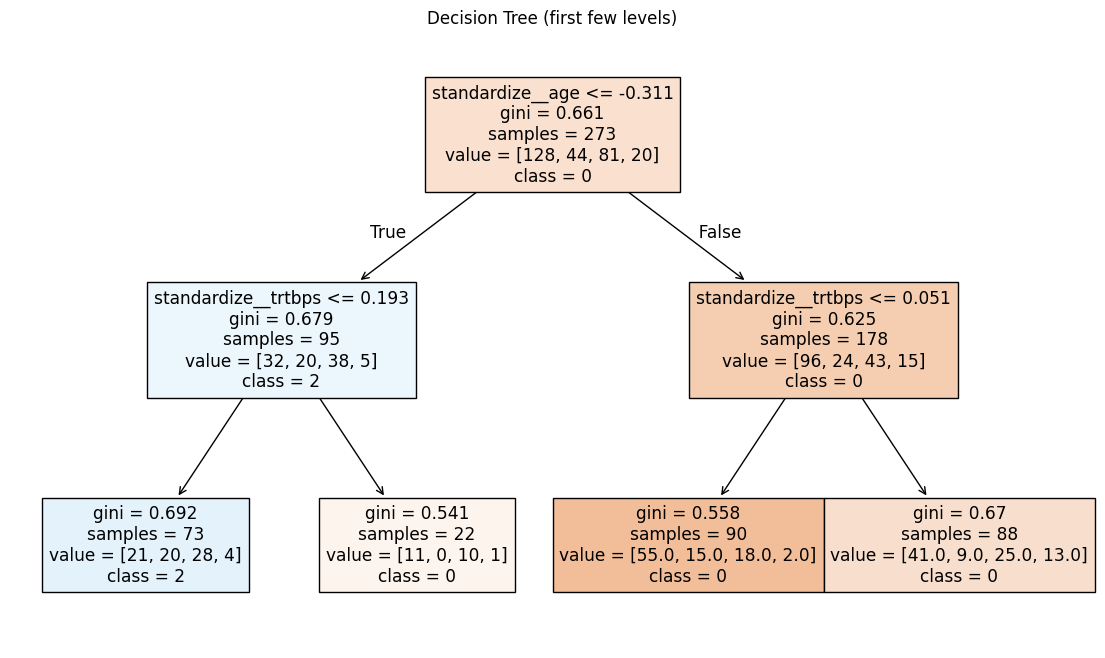

In [11]:
import matplotlib.pyplot as plt
from sklearn import tree as sktree

best_dt = dt_grid.best_estimator_
feature_names = best_dt.named_steps["preprocessing"].get_feature_names_out()

plt.figure(figsize=(14, 8))
sktree.plot_tree(
    best_dt.named_steps["tree"],
    feature_names=feature_names,
    class_names=["0","1","2","3"],
    filled=True,
    max_depth=3
)
plt.title("Decision Tree (first few levels)")
plt.show()

In [12]:
# LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_pipeline = Pipeline([
    ("preprocessing", ct),
    ("lda", LinearDiscriminantAnalysis())
])

lda_cv = cross_val_score(lda_pipeline, X, y, cv=5, scoring="accuracy")
lda_pipeline.fit(X, y)

print("LDA accuracy:", lda_cv.mean(), "±", lda_cv.std())

LDA accuracy: 0.4430976430976431 ± 0.029371387633204547


## Q2:  OvR

Create a new column in the `ha` dataset called `cp_is_3`, which is equal to `1` if the `cp` variable is equal to `3` and `0` otherwise.

Then, fit a Logistic Regression to predict this new target, and report the **F1 Score**.

Repeat for the other three `cp` categories.  Which category was the OvR approach best at distinguishing?

In [13]:
ha["cp_is_3"] = (ha["cp"] == 3).astype(int)

X = ha[["trtbps", "chol", "age"]]
y = ha["cp_is_3"]


logistic_model =Pipeline(
    [("scale", StandardScaler()),
    ("model", LogisticRegression())]
)

logistic_model.fit(X, y)

Pipeline(steps=[('scale', StandardScaler()), ('model', LogisticRegression())])

In [14]:
cross_val_score(logistic_model, X, y,
                                cv=5, scoring="f1").mean()

np.float64(0.0)

In [15]:
ha["cp_is_0"] = (ha["cp"] == 0).astype(int)

X = ha[["trtbps", "chol", "age"]]
y = ha["cp_is_0"]


logistic_model2 =Pipeline(
    [("scale", StandardScaler()),
    ("model", LogisticRegression())]
)

logistic_model2.fit(X, y)

Pipeline(steps=[('scale', StandardScaler()), ('model', LogisticRegression())])

In [16]:
cross_val_score(logistic_model2, X, y,
                                cv=5, scoring="f1").mean()

np.float64(0.4624250522492891)

In [17]:
ha["cp_is_1"] = (ha["cp"] == 1).astype(int)

X = ha[["trtbps", "chol", "age"]]
y = ha["cp_is_1"]


logistic_model3 =Pipeline(
    [("scale", StandardScaler()),
    ("model", LogisticRegression())]
)

logistic_model3.fit(X, y)

Pipeline(steps=[('scale', StandardScaler()), ('model', LogisticRegression())])

In [18]:
cross_val_score(logistic_model3, X, y,
                                cv=5, scoring="f1").mean()

np.float64(0.0)

In [19]:
ha["cp_is_2"] = (ha["cp"] == 2).astype(int)

X = ha[["trtbps", "chol", "age"]]
y = ha["cp_is_2"]


logistic_model4 =Pipeline(
    [("scale", StandardScaler()),
    ("model", LogisticRegression())]
)

logistic_model4.fit(X, y)

Pipeline(steps=[('scale', StandardScaler()), ('model', LogisticRegression())])

In [20]:
cross_val_score(logistic_model4, X, y,
                                cv=5, scoring="f1").mean()

np.float64(0.0)

The category that the OvR approach is best at distinguishing in category 0, asymptomatic.

## Q3: OvO

Reduce your dataset to only the `0` and `1` types of chest pain.

Then, fit a Logistic Regression to predict between the two groups, and report the **ROC-AUC**.  

Repeat comparing category `0` to `2` and `3`.  Which pair was the OvO approach best at distinguishing?

In [21]:
ha_01 = ha[(ha["cp"] == 0) | (ha["cp"] == 1)]

X = ha_01[["trtbps", "chol", "age"]]
y = ha_01["cp"]


logistic_model =Pipeline(
    [("scale", StandardScaler()),
    ("model", LogisticRegression())]
)

logistic_model.fit(X, y)

Pipeline(steps=[('scale', StandardScaler()), ('model', LogisticRegression())])

In [36]:
from sklearn.metrics import roc_auc_score, roc_curve

y_pred_proba_01 = logistic_model.predict_proba(X)[:, 1]
roc_auc_01 = roc_auc_score(y, y_pred_proba_01)
print("ROC-AUC for 0 vs 1:", roc_auc_01)

ROC-AUC for 0 vs 1: 0.6450639204545454


In [30]:
ha_02 = ha[(ha["cp"] == 0) | (ha["cp"] == 2)]

X_02 = ha_02[["trtbps", "chol", "age"]]
y_02 = ha_02["cp"]

logistic_model_02 = Pipeline(
    [("scale", StandardScaler()),
    ("model", LogisticRegression())]
)

logistic_model_02.fit(X_02, y_02)

Pipeline(steps=[('scale', StandardScaler()), ('model', LogisticRegression())])

In [35]:
y_pred_proba_02 = logistic_model_02.predict_proba(X_02)[:, 1]
roc_auc_02 = roc_auc_score(y_02, y_pred_proba_02)
print("ROC-AUC for 0 vs 2:", roc_auc_02)

ROC-AUC for 0 vs 2: 0.6070601851851851


In [32]:
ha_03 = ha[(ha["cp"] == 0) | (ha["cp"] == 3)]

X_03 = ha_03[["trtbps", "chol", "age"]]
y_03 = ha_03["cp"]

logistic_model_03 = Pipeline(
    [("scale", StandardScaler()),
    ("model", LogisticRegression())]
)

logistic_model_03.fit(X_03, y_03)

Pipeline(steps=[('scale', StandardScaler()), ('model', LogisticRegression())])

In [34]:
y_pred_proba_03 = logistic_model_03.predict_proba(X_03)[:, 1]
roc_auc_03 = roc_auc_score(y_03, y_pred_proba_03)
print("ROC-AUC for 0 vs 3:",roc_auc_03)

ROC-AUC for 0 vs 3: 0.684375


OvO was best at distinguishing pair 0 and 3.